In [180]:
import numpy as np
import pandas as pd

df = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values(by=['indicator', 'date'], inplace=True)

# Limit to the last 100 unique dates
latest_dates = df['date'].drop_duplicates().sort_values().tail(100)
df = df[df['date'].isin(latest_dates)]

df[df['indicator'] == '146.71.50.198']

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
90354,818860012482918321,2025-02-11,146.71.50.198,0,1,False,11,2,0
90576,818860012482918321,2025-02-12,146.71.50.198,0,2,False,12,2,0
90798,818860012482918321,2025-02-13,146.71.50.198,0,3,False,13,2,0
91020,818860012482918321,2025-02-14,146.71.50.198,0,4,False,14,2,0
91242,818860012482918321,2025-02-15,146.71.50.198,0,5,True,15,2,0
...,...,...,...,...,...,...,...,...,...
111444,818860012482918321,2025-05-17,146.71.50.198,0,5,True,17,5,0
111666,818860012482918321,2025-05-18,146.71.50.198,0,6,True,18,5,0
111888,818860012482918321,2025-05-19,146.71.50.198,0,0,False,19,5,0
112110,818860012482918321,2025-05-20,146.71.50.198,0,1,False,20,5,0


In [161]:
# Function to extract features per indicator
def extract_time_series_features(group):
    series = group['seen'].values
    dates = group['date'].values

    indices = np.where(series == 1)[0]
    if len(indices) == 0:
        return pd.Series({
            'last_seen': len(series),
            'freq_7': 0,
            'freq_30': 0,
            'avg_gap': len(series),
            'burstiness': 0,
            'label_7': 0,
            'label_14': 0,
            'label_30': 0
        })

    last_seen = len(series) - 1 - indices[-1] # Number of days since the IP was last seen. Recent = low value. Captures recency.
    freq_7 = np.sum(series[-7:]) # Count of days seen in the last 7 days. Measures short-term activity.
    freq_30 = np.sum(series[-30:]) # Count of days seen in the last 30 days. Measures medium-term activity.
    gaps = np.diff(indices)
    avg_gap = np.mean(gaps) if len(gaps) > 0 else len(series) # Average time (in days) between two consecutive sightings. Shows periodicity.
    burstiness = (np.std(gaps) - avg_gap) / (np.std(gaps) + avg_gap) if len(gaps) > 1 else 0 # Measures how irregular or volatile the sightings are. Based on standard deviation of gaps: Ranges from -1 (very regular) to +1 (very bursty).
    label_7 = 1 if np.any(series[-7:]) else 0
    label_14 = 1 if np.any(series[-14:]) else 0
    label_30 = 1 if np.any(series[-30:]) else 0

    return pd.Series({
        'last_seen': last_seen,
        'freq_7': freq_7,
        'freq_30': freq_30,
        'avg_gap': avg_gap,
        'burstiness': burstiness,
        'label_7': label_7,
        'label_14': label_14,
        'label_30': label_30
    })

# Apply to each indicator group
features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()

C:\Users\jaskew\AppData\Local\Temp\ipykernel_22212\1570248052.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()


In [162]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lifelines import WeibullAFTFitter
from scipy.stats import expon
import numpy as np

# Copy features into a separate DataFrame for modeling
df_pred = features_df.copy()

# Define features and labels
X = df_pred[['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']]
y_7 = df_pred['label_7']
y_14 = df_pred['label_14']
y_30 = df_pred['label_30']

# Helper functions
def train_predict(model_cls, X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([('scaler', StandardScaler()), ('clf', model_cls())])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

def train_gbt(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = GradientBoostingClassifier()
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

# Logistic Regression Predictions
df_pred['logistic_7'] = train_predict(LogisticRegression, X, y_7)
df_pred['logistic_14'] = train_predict(LogisticRegression, X, y_14)
df_pred['logistic_30'] = train_predict(LogisticRegression, X, y_30)

# Gradient Boosted Tree Predictions
df_pred['gbt_7'] = train_gbt(X, y_7)
df_pred['gbt_14'] = train_gbt(X, y_14)
df_pred['gbt_30'] = train_gbt(X, y_30)

# Exponential Model (Poisson-based) P(\text{seen in } t \text{ days}) = 1 - e^{-λt}, \quad \text{where } λ = \frac{\text{freq_30}}{30}
rate = (df_pred['freq_30'] / 30).clip(lower=1e-6)
df_pred['exp_7'] = 1 - np.exp(-rate * 7)
df_pred['exp_14'] = 1 - np.exp(-rate * 14)
df_pred['exp_30'] = 1 - np.exp(-rate * 30)

# Weibull AFT Model A survival model that predicts time until next sighting.
aft_df = X.copy()
aft_df['duration'] = df_pred['avg_gap']
aft_df['event'] = y_7

aft = WeibullAFTFitter()
aft.fit(aft_df, duration_col='duration', event_col='event')

# Predict survival function at 1, 7, 14, 30 days
surv_func = aft.predict_survival_function(aft_df, times=[1, 7, 14, 30])
df_pred['weibull_today'] = 1 - surv_func.loc[1].values
df_pred['weibull_7'] = 1 - surv_func.loc[7].values
df_pred['weibull_14'] = 1 - surv_func.loc[14].values
df_pred['weibull_30'] = 1 - surv_func.loc[30].values

# Today's forecast
df_pred['exp_today'] = 1 - np.exp(-rate * 1)
df_pred['logistic_today'] = safe_train_predict(LogisticRegression, X, y_7)
df_pred['gbt_today'] = train_gbt(X, y_7)

# Merge in actual "seen" value for today's date
latest_date = df['date'].max()
today_seen = df[df['date'] == latest_date][['indicator', 'seen']].rename(columns={'seen': 'seen_today'})
df_pred = df_pred.merge(today_seen, on='indicator', how='left')

# Final output
output = df_pred[[
    'indicator', 'seen_today', 'last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness',
    'exp_today', 'exp_7', 'exp_14', 'exp_30',
    'weibull_today', 'weibull_7', 'weibull_14', 'weibull_30',
    'logistic_today', 'logistic_7', 'logistic_14', 'logistic_30',
    'gbt_today', 'gbt_7', 'gbt_14', 'gbt_30'
]]

display(output)


,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.129.153.158,0,54.0,0.0,0.0,21.0000,0.000000,9.999995e-07,0.000007,0.000014,...,1.077178e-06,2.011080e-05,0.004099,0.004099,0.003330,0.050345,0.000012,0.000012,0.000018,0.000025
1,102.129.153.43,0,5.0,1.0,2.0,31.0000,-0.352092,6.449301e-02,0.372911,0.606759,...,6.234220e-02,6.993465e-01,0.797448,0.797448,0.909054,0.986553,0.999969,0.999969,0.999974,0.999982
2,102.129.153.71,0,27.0,0.0,1.0,15.5000,-0.097822,3.278390e-02,0.208110,0.372911,...,2.079502e-03,3.811933e-02,0.028840,0.028840,0.111755,0.711906,0.000012,0.000012,0.000018,0.999982
3,102.165.16.161,0,41.0,0.0,0.0,6.0000,-0.381966,9.999995e-07,0.000007,0.000014,...,6.679014e-05,1.246241e-03,0.011483,0.011483,0.021778,0.275039,0.000012,0.000012,0.000018,0.000025
4,104.160.6.2,0,28.0,0.0,2.0,20.5000,-0.025000,6.449301e-02,0.372911,0.606759,...,1.523378e-03,2.806201e-02,0.027971,0.027971,0.111081,0.744316,0.000012,0.000012,0.000018,0.999982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,international.standardbank.com/,0,100.0,0.0,0.0,100.0000,0.000000,9.999995e-07,0.000007,0.000014,...,9.992007e-16,1.842970e-14,0.000213,0.000213,0.000010,0.000103,0.000012,0.000012,0.000018,0.000025
218,pub.marq.com/,0,7.0,0.0,1.0,9.6000,0.122880,3.278390e-02,0.208110,0.372911,...,6.585097e-01,1.000000e+00,0.096641,0.096641,0.573843,0.964355,0.000012,0.000012,0.999974,0.999982
219,realinvestmentadvice.com/,0,2.0,1.0,4.0,8.0000,0.021684,1.248267e-01,0.606759,0.845362,...,9.999443e-01,1.000000e+00,0.808824,0.808824,0.942675,0.995045,0.999969,0.999969,0.999974,0.999982
220,www.emergencylighting.com/,1,0.0,1.0,1.0,49.5000,-0.010204,3.278390e-02,0.208110,0.372911,...,4.028886e-02,5.359525e-01,0.827827,0.827827,0.925177,0.985457,0.999969,0.999969,0.999974,0.999982


In [163]:
output.drop(columns=['indicator'])

,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,exp_30,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,0,54.0,0.0,0.0,21.0000,0.000000,9.999995e-07,0.000007,0.000014,0.000030,...,1.077178e-06,2.011080e-05,0.004099,0.004099,0.003330,0.050345,0.000012,0.000012,0.000018,0.000025
1,0,5.0,1.0,2.0,31.0000,-0.352092,6.449301e-02,0.372911,0.606759,0.864665,...,6.234220e-02,6.993465e-01,0.797448,0.797448,0.909054,0.986553,0.999969,0.999969,0.999974,0.999982
2,0,27.0,0.0,1.0,15.5000,-0.097822,3.278390e-02,0.208110,0.372911,0.632121,...,2.079502e-03,3.811933e-02,0.028840,0.028840,0.111755,0.711906,0.000012,0.000012,0.000018,0.999982
3,0,41.0,0.0,0.0,6.0000,-0.381966,9.999995e-07,0.000007,0.000014,0.000030,...,6.679014e-05,1.246241e-03,0.011483,0.011483,0.021778,0.275039,0.000012,0.000012,0.000018,0.000025
4,0,28.0,0.0,2.0,20.5000,-0.025000,6.449301e-02,0.372911,0.606759,0.864665,...,1.523378e-03,2.806201e-02,0.027971,0.027971,0.111081,0.744316,0.000012,0.000012,0.000018,0.999982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,0,100.0,0.0,0.0,100.0000,0.000000,9.999995e-07,0.000007,0.000014,0.000030,...,9.992007e-16,1.842970e-14,0.000213,0.000213,0.000010,0.000103,0.000012,0.000012,0.000018,0.000025
218,0,7.0,0.0,1.0,9.6000,0.122880,3.278390e-02,0.208110,0.372911,0.632121,...,6.585097e-01,1.000000e+00,0.096641,0.096641,0.573843,0.964355,0.000012,0.000012,0.999974,0.999982
219,0,2.0,1.0,4.0,8.0000,0.021684,1.248267e-01,0.606759,0.845362,0.981684,...,9.999443e-01,1.000000e+00,0.808824,0.808824,0.942675,0.995045,0.999969,0.999969,0.999974,0.999982
220,1,0.0,1.0,1.0,49.5000,-0.010204,3.278390e-02,0.208110,0.372911,0.632121,...,4.028886e-02,5.359525e-01,0.827827,0.827827,0.925177,0.985457,0.999969,0.999969,0.999974,0.999982


In [164]:
output[output['indicator'] == '102.129.153.158']

,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.129.153.158,0,54.0,0.0,0.0,21.0,0.0,9.999995e-07,0.000007,0.000014,...,0.000001,0.00002,0.004099,0.004099,0.00333,0.050345,0.000012,0.000012,0.000018,0.000025


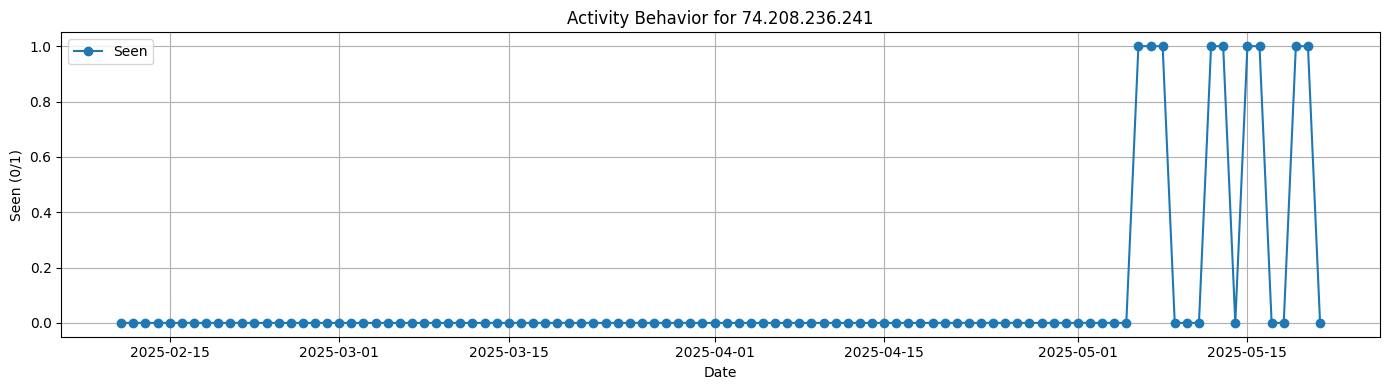

In [176]:
import matplotlib.pyplot as plt

indicator_id = '74.208.236.241'
df_plot = df[df['indicator'] == indicator_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
plt.title(f'Activity Behavior for {indicator_id}')
plt.xlabel('Date')
plt.ylabel('Seen (0/1)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
output[output['indicator'] == '113.96.236.11']

,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
12,113.96.236.11,0,62.0,0.0,0.0,1.75,-0.357033,9.999995e-07,0.000007,0.000014,...,5.861567e-07,0.000011,0.002588,0.002588,0.001576,0.026971,0.000012,0.000012,0.000018,0.000025


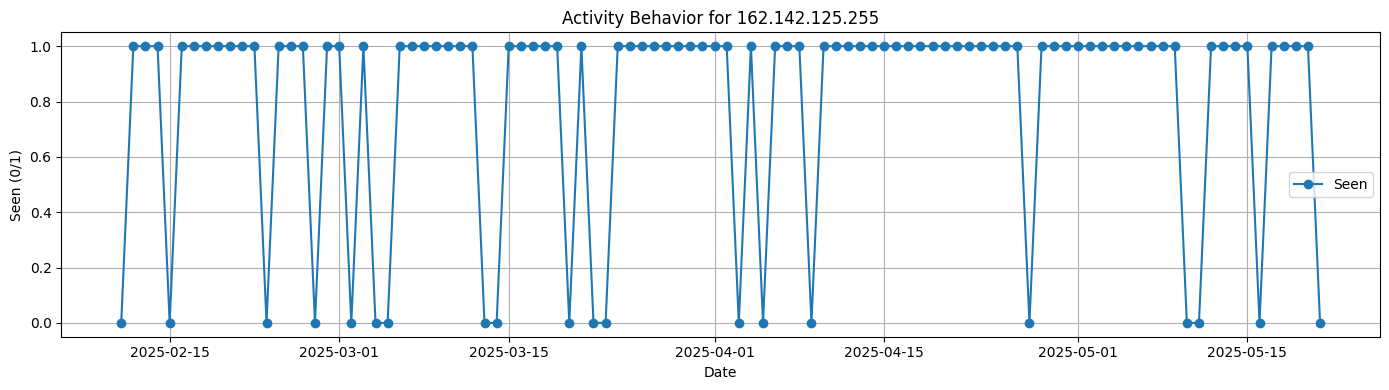

In [179]:
indicator_id = '162.142.125.255'
df_plot = df[df['indicator'] == indicator_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
plt.title(f'Activity Behavior for {indicator_id}')
plt.xlabel('Date')
plt.ylabel('Seen (0/1)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [168]:
df[(df['seen'] ==0) & (df['date'] == pd.Timestamp('2025-05-21'))]

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
112493,818860012482918321,2025-05-21,102.129.153.158,0,2,False,21,5,0
112476,818860012482918321,2025-05-21,102.129.153.43,0,2,False,21,5,0
112344,818860012482918321,2025-05-21,102.129.153.71,0,2,False,21,5,0
112494,818860012482918321,2025-05-21,102.165.16.161,0,2,False,21,5,0
112499,818860012482918321,2025-05-21,104.160.6.2,0,2,False,21,5,0
...,...,...,...,...,...,...,...,...,...
112359,818860012482918321,2025-05-21,geo.netsupportsoftware.com/location/loca.asp,0,2,False,21,5,0
112487,818860012482918321,2025-05-21,hcmiu.edu.vn/,0,2,False,21,5,0
112443,818860012482918321,2025-05-21,international.standardbank.com/,0,2,False,21,5,0
112521,818860012482918321,2025-05-21,pub.marq.com/,0,2,False,21,5,0


In [175]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lifelines import WeibullAFTFitter
from scipy.stats import expon
import numpy as np

#  Define features and labels ---
features = ['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']
X = output[features]

#  Rule-Based Binary Labels Using last_seen ---
output['rule_today'] = output['last_seen'].apply(lambda x: 1 if x == 0 else 0)
output['rule_7d'] = output['last_seen'].apply(lambda x: 1 if x <= 6 else 0)
output['rule_14d'] = output['last_seen'].apply(lambda x: 1 if x <= 13 else 0)
output['rule_30d'] = output['last_seen'].apply(lambda x: 1 if x <= 29 else 0)

y_today = output['rule_today']
y_7 = output['rule_7d']
y_14 = output['rule_14d']
y_30 = output['rule_30d']

#  Logistic Regression Model ---
def train_logistic_model(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression())
    ])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

output['prob_today'] = train_logistic_model(X, y_today)
output['prob_7d'] = train_logistic_model(X, y_7)
output['prob_14d'] = train_logistic_model(X, y_14)
output['prob_30d'] = train_logistic_model(X, y_30)

#  Ensemble Probabilities ---
output['ensemble_7d'] = (
    0.3 * output['prob_7d'].astype(float) +
    0.25 * output['gbt_7'] +
    0.25 * output['weibull_7'] +
    0.3 * output['exp_7']
)

output['ensemble_14d'] = (
    0.3 * output['prob_14d'].astype(float) +
    0.25 * output['gbt_14'] +
    0.25* output['weibull_14'] +
    0.3 * output['exp_14']
)

output['ensemble_30d'] = (
    0.3 * output['prob_30d'].astype(float) +
    0.25 * output['gbt_14'] +
    0.25 * output['weibull_30'] +
    0.3 * output['exp_30']
)

#  Confidence Tags ---
def classify_window(prob, freq_7, high_thresh, label):
    if prob >= high_thresh and freq_7 >= 2:
        return f"{label}: Highly likely"
    elif prob >= 0.07 and freq_7 >= 1:
        return f"{label}: Possibly active"
    else:
        return f"{label}: Low confidence"

output['confidence_today'] = output.apply(
    lambda row: classify_window(
        float(row['prob_today'].strip('%')) / 100 if isinstance(row['prob_today'], str) else row['prob_today'],
        row['freq_7'], 0.6, 'Today'
    ), axis=1
)

output['confidence_7d'] = output.apply(
    lambda row: classify_window(
        float(row['ensemble_7d'].strip('%')) / 100 if isinstance(row['ensemble_7d'], str) else row['ensemble_7d'],
        row['freq_7'], 0.6, '7-Day'
    ), axis=1
)

output['confidence_14d'] = output.apply(
    lambda row: classify_window(
        float(row['ensemble_14d'].strip('%')) / 100 if isinstance(row['ensemble_14d'], str) else row['ensemble_14d'],
        row['freq_7'], 0.6, '14-Day'
    ), axis=1
)

output['confidence_30d'] = output.apply(
    lambda row: classify_window(
        float(row['ensemble_30d'].strip('%')) / 100 if isinstance(row['ensemble_30d'], str) else row['ensemble_30d'],
        row['freq_7'], 0.6, '30-Day'
    ), axis=1
)

#  Format Percentages ---
for col in ['prob_7d', 'prob_14d', 'prob_30d', 'ensemble_7d', 'ensemble_14d', 'ensemble_30d']:
    output[col] = (output[col] * 100).round(2).astype(str) + '%'

#  Format Today prob ---
output['prob_today'] = (output['prob_today'].astype(float) * 100).round(2).astype(str) + '%'

#  Final Output ---
production_output = output[[
    'indicator', 'seen_today', 'freq_7', 'freq_30',
    'prob_today', 'confidence_today',
    'ensemble_7d', 'confidence_7d',
    'ensemble_14d', 'confidence_14d',
    'ensemble_30d', 'confidence_30d'
]].copy()

# --- Rename for display ---
production_output.rename(columns={
    'indicator': 'Indicator',
    'seen_today': 'Observed Today',
    'freq_7': 'Frequency (7d)',
    'freq_30': 'Frequency (30d)',
    'prob_today': 'Probability: Today',
    'confidence_today': 'Confidence: Today',
    'ensemble_7d': 'Probability: 7-Day',
    'confidence_7d': 'Confidence: 7-Day',
    'ensemble_14d': 'Probability: 14-Day',
    'confidence_14d': 'Confidence: 14-Day',
    'ensemble_30d': 'Probability: 30-Day',
    'confidence_30d': 'Confidence: 30-Day'
}, inplace=True)

display(production_output)



,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day
0,102.129.153.158,0,0.0,0.0,0.46%,Today: Low confidence,0.12%,7-Day: Low confidence,0.1%,14-Day: Low confidence,1.51%,30-Day: Low confidence
1,102.129.153.43,0,1.0,2.0,2.2%,Today: Low confidence,60.22%,7-Day: Possibly active,72.03%,14-Day: Possibly active,98.02%,30-Day: Possibly active
2,102.129.153.71,0,0.0,1.0,0.8%,Today: Low confidence,7.11%,7-Day: Low confidence,14.59%,14-Day: Low confidence,41.27%,30-Day: Low confidence
3,102.165.16.161,0,0.0,0.0,0.26%,Today: Low confidence,0.35%,7-Day: Low confidence,0.66%,14-Day: Low confidence,8.28%,30-Day: Low confidence
4,104.160.6.2,0,0.0,2.0,0.85%,Today: Low confidence,12.03%,7-Day: Low confidence,21.57%,14-Day: Low confidence,48.97%,30-Day: Low confidence
...,...,...,...,...,...,...,...,...,...,...,...,...
217,international.standardbank.com/,0,0.0,0.0,0.06%,Today: Low confidence,0.01%,7-Day: Low confidence,0.0%,14-Day: Low confidence,0.0%,30-Day: Low confidence
218,pub.marq.com/,0,0.0,1.0,2.97%,Today: Low confidence,10.95%,7-Day: Low confidence,69.86%,14-Day: Low confidence,97.89%,30-Day: Low confidence
219,realinvestmentadvice.com/,0,1.0,4.0,6.55%,Today: Low confidence,79.85%,7-Day: Possibly active,103.64%,14-Day: Possibly active,109.3%,30-Day: Possibly active
220,www.emergencylighting.com/,1,1.0,1.0,6.48%,Today: Low confidence,56.15%,7-Day: Possibly active,64.95%,14-Day: Possibly active,86.93%,30-Day: Possibly active
